# **SPECTRA-CQ Phase 4: Multi-Sensor Data Preprocessing and EDA**

This notebook serves as the execution terminal to process the raw openLAB dataset into synchronized 6-channel tensors.

These tensors map the physical geometry of spans 1 and 2 $\implies$ act as the foundation for the 12-qubit Siamese `bridge_graph` architecture.

In [ ]:
from google.colab import drive
import os
import sys
import numpy as np
import glob

# Mount Data Drive
drive.mount('/content/drive')

# Clone Github Repository
GITHUB_TOKEN = "PAT" # Scrubbed for security
REPO_URL = f"https://{GITHUB_TOKEN}@github.com/yeshapan/SPECTRA-CQ.git"

!git clone {REPO_URL}
%cd SPECTRA-CQ
!pip install -r requirements.txt

# Ensure local src imports work seamlessly in Colab
sys.path.append(os.path.abspath('.'))

Mounted at /content/drive
Cloning into 'SPECTRA-CQ'...
remote: Enumerating objects: 322, done.
remote: Counting objects: 100% (249/249), done.
remote: Compressing objects: 100% (164/164), done.
remote: Total 322 (delta 106), reused 208 (delta 66), pack-reused 73 (from 1)
Receiving objects: 100% (322/322), 34.14 MiB | 26.38 MiB/s, done.
Resolving deltas: 100% (116/116), done.
/content/SPECTRA-CQ
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.8/60.8 kB 2.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 937.5/937.5 kB 8.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.7/6.7 MB 11.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 231.9/231.9 kB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.8/40.8 MB 9.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.5/25

### **1. Data Ingestion + CWT Processing**
Execute the external data processing pipeline.

This reads all target Z-axis accelerometers simultaneously, applies the Continuous Wavelet Transform and stacks them into `(6, 64, 1000)` matrices.

In [2]:
# Validate mount paths for the Phase 4 multi-channel data
# Use local Colab storage for fast I/O writes
RAW_DATA_PATH = "/content/drive/MyDrive/spectra-cq-data/raw_csv"
LOCAL_OUTPUT_PATH = "/content/processed_spectrograms_6ch"
DRIVE_ARCHIVE_PATH = "/content/drive/MyDrive/spectra-cq-data/spectra_matrices_6ch.zip"

!python src/data/preprocess.py \
    --input_dir {RAW_DATA_PATH} \
    --output_dir {LOCAL_OUTPUT_PATH} \
    --window 2

# Zip the local folder and move to Drive for permanent storage
print("Zipping multi-channel matrices..")
!zip -r -q {DRIVE_ARCHIVE_PATH} {LOCAL_OUTPUT_PATH}
print(f"Archive saved to {DRIVE_ARCHIVE_PATH}")

2026-06-28 15:20:06,889 - INFO - Initialized processing pipeline for 526 files. Target nodes: 6-Sensor Fusion.
Applying CWT via Morlet Kernel: 100% 526/526 [30:50<00:00,  3.52s/it]
2026-06-28 15:50:57,727 - INFO - Pipeline complete. Yielded 9765 multi-channel spectrograms (float32).
Zipping multi-channel matrices..


zip error: Interrupted (aborting)
Archive saved to /content/drive/MyDrive/spectra-cq-data/spectra_matrices_6ch.zip


> *NOTE: This previous cell was causing IO bottleneck and taking too long and also Google Colab runtime got disconnected so I stopped execution and ran the cell below*

> *NOTE: The printed statement "Archive saved to /content/drive/MyDrive/spectra-cq-data/spectra_matrices_6ch.zip" is a false positive - because the Python script doesn't automatically halt when interrupted so it just printed the next line*

In [7]:
import os
import glob

# 1. Clean up the broken files
!rm -f /content/.*.zip* # Removes hidden temp files
!rm -f /content/.ziixG5CX
!rm -f /content/spectra_matrices_6ch.zip
print("Cleaned up corrupted zip files.")

# 2. Check if the original data survived the restart
data_dir = "/content/processed_spectrograms_6ch"
if os.path.exists(data_dir):
    survivors = glob.glob(f"{data_dir}/*.npy")
    print(f"Found {len(survivors)} files remaining.")
else:
    survivors = []
    print("Directory not found.")

# 3. Execute safe transfer or report failure
if len(survivors) == 9765:
    print("All data survived! Archiving without compression to prevent RAM crashes..")
    # -0 flag tells Linux to just group the files, not compress them.
    !zip -0 -r -q /content/spectra_matrices_6ch.zip {data_dir}

    print("Archive created. Transferring to Drive...")
    !cp /content/spectra_matrices_6ch.zip /content/drive/MyDrive/spectra-cq-data/
    print("Transfer complete! You are safe.")

else:
    print("You need to re-run processing cell")

Cleaned up corrupted zip files.
Found 9765 files remaining.
All data survived! Archiving without compression to prevent RAM crashes..
Archive created. Transferring to Drive...
Transfer complete! You are safe.


### **2. Physical Inspection (EDA)**
Load a single generated tensor to verify the channel stacking mechanism and visually inspect the structural energy synchronization across the 3x2 physical bridge grid.

Ingested Tensor Shape: (6, 64, 1000) 
Expected Target: (6, 64, 1000)



/content/SPECTRA-CQ/src/utils/viz.py:209: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


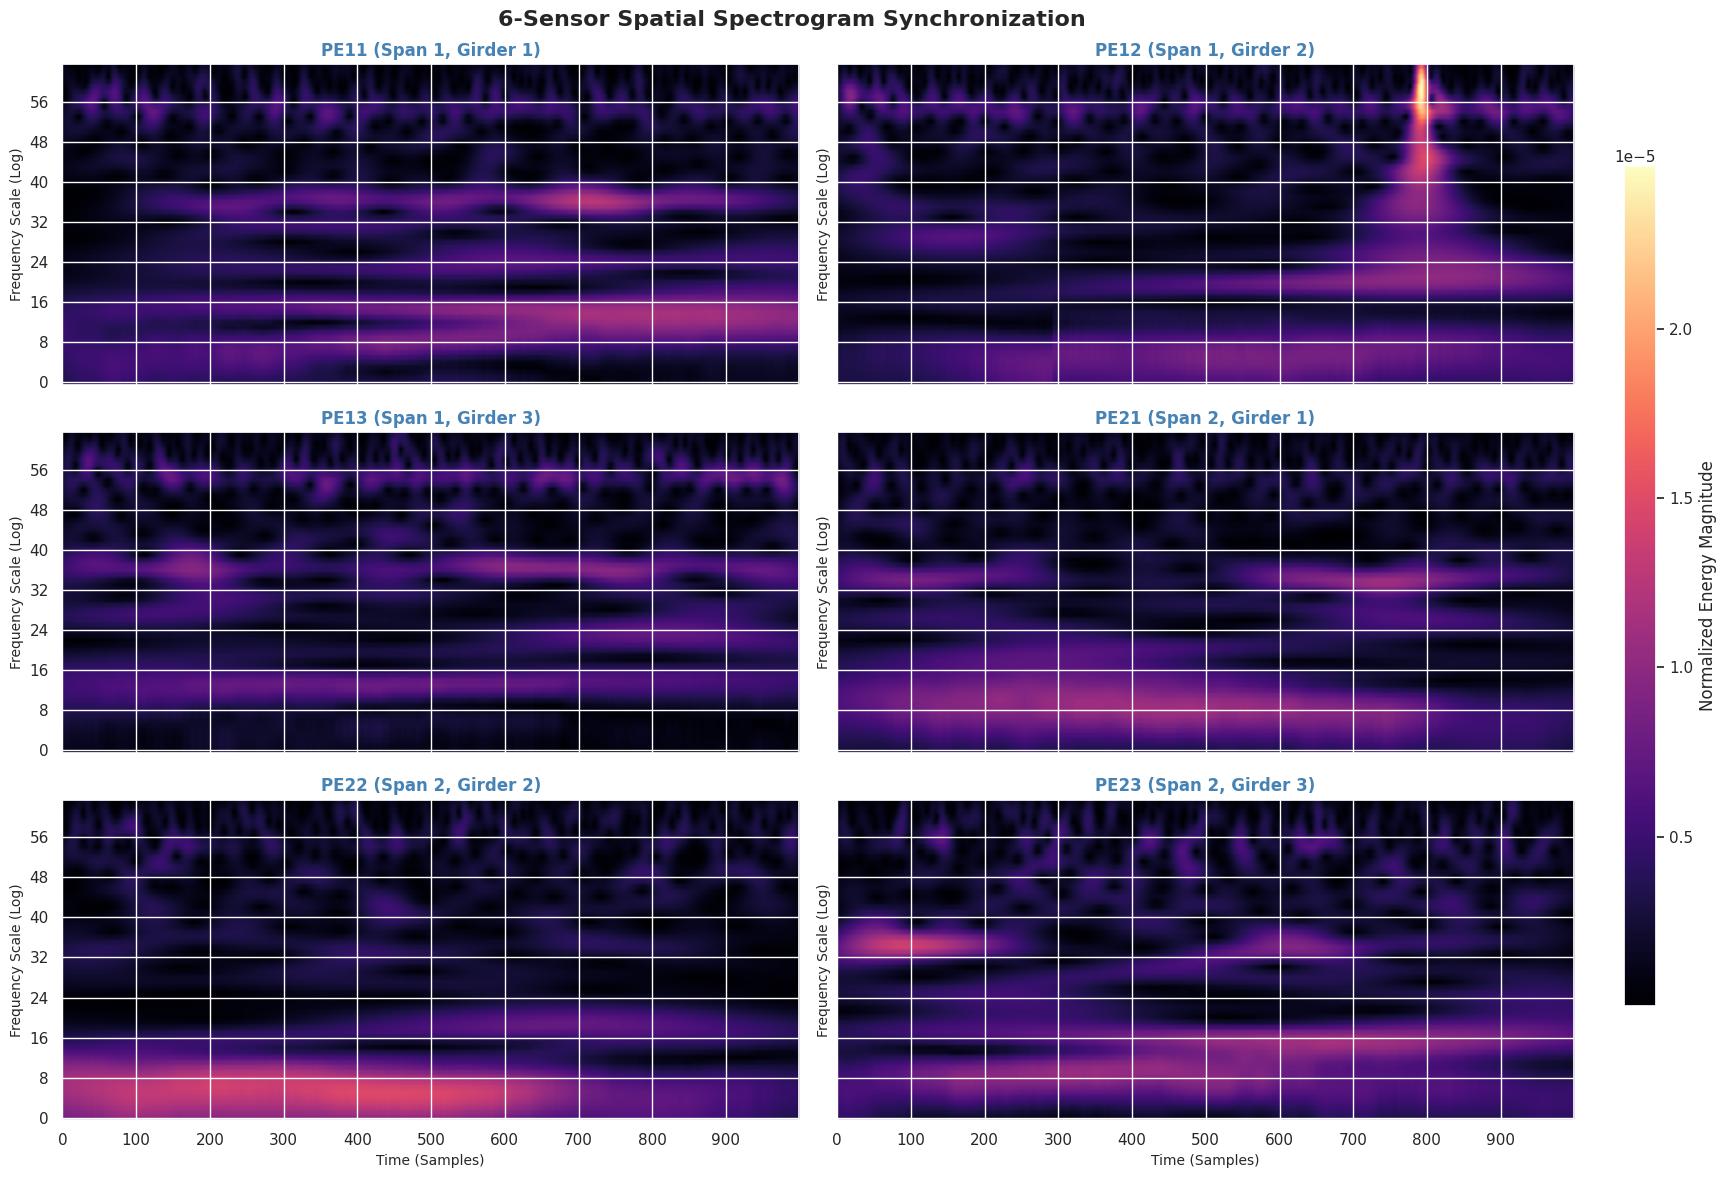

In [6]:
from src.utils.viz import plot_multi_sensor_spectrograms

# Fetch the first generated 6-channel sample from the local drive
sample_files = glob.glob(os.path.join(LOCAL_OUTPUT_PATH, "*.npy"))
assert len(sample_files) > 0, "No matrices found. Ensure preprocessing completed successfully."

sample_tensor = np.load(sample_files[0])
print(f"Ingested Tensor Shape: {sample_tensor.shape} \nExpected Target: (6, 64, 1000)\n")

# Pass to visualization utility to map the 3x2 physical geometry
plot_multi_sensor_spectrograms(sample_tensor)